# Exploración y Limpieza de Datos de Insiders

Este notebook sirve para limpiar los datos crudos obtenidos de OpenInsider y preparar las primeras features para nuestro modelo de Machine Learning.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml

# Configuración de visualización
sns.set(style="whitegrid")
%matplotlib inline

## 1. Carga de Datos
Cargamos la configuración y el archivo CSV generado por el scraper.

In [20]:
project_root = Path("../..")
with open(project_root / 'config' / 'config.yaml', 'r') as f:
    config = yaml.safe_load(f)

raw_data_path = project_root / config['output']['directory'] / config['output']['filename']
df = pd.read_csv(raw_data_path)

print(f"Filas cargadas: {len(df)}")
df.head()

Filas cargadas: 10593


,transaction_date,trade_date,ticker,company_name,owner_name,Title,transaction_type,last_price,Qty,shares_held,Owned,Value
0,2025-05-12 16:14:02,2025-05-08,MAIA,"Maia Biotechnology, Inc.",Guerrero Ramiro,Dir,P,$1.50,"+20,000","588,218",+4%,"+$30,000"
1,2025-05-30 13:35:57,2025-05-29,TPL,Texas Pacific Land Corp,Stahl Murray,Dir,P,"$1,218.09",+10,"1,166,111",0%,"+$12,181"
2,2025-05-12 07:28:08,2025-05-09,ENR,"Energizer Holdings, Inc.",Lavigne Mark Stephen,"Pres, CEO",P,$21.67,"+4,000","277,645",+1%,"+$86,680"
3,2025-05-27 19:00:32,2025-05-22,BLIN,"Bridgeline Digital, Inc.",Kahn Roger E.,"Pres, CEO, 10%",P,$1.55,"+100,100","1,156,932",+9%,"+$155,591"
4,2025-05-21 16:10:05,2025-05-19,FLOC,Flowco Holdings Inc.,Hobby Paul W,Dir,P,$19.00,+500,"28,040",+2%,"+$9,500"


## 2. Limpieza de Fechas e Identificadores

In [21]:
df['filing_date'] = pd.to_datetime(df['transaction_date'])
df['trade_date'] = pd.to_datetime(df['trade_date'])

df[['ticker', 'filing_date', 'trade_date']].head()

,ticker,filing_date,trade_date
0,MAIA,2025-05-12 16:14:02,2025-05-08
1,TPL,2025-05-30 13:35:57,2025-05-29
2,ENR,2025-05-12 07:28:08,2025-05-09
3,BLIN,2025-05-27 19:00:32,2025-05-22
4,FLOC,2025-05-21 16:10:05,2025-05-19


## 3. Limpieza de Valores Numéricos
OpenInsider devuelve los valores como strings (ej: `$1,200`). Los convertimos a float.

In [22]:
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('+', '', regex=False)
        .str.replace('%', '', regex=False),
        errors='coerce'
    ).fillna(0)

df['qty_cleaned'] = clean_numeric(df['Qty'])
df['owned_after_cleaned'] = clean_numeric(df['shares_held'])
df['transaction_value'] = clean_numeric(df['Value'])
df['owned_pct_change'] = clean_numeric(df['Owned']) # El +2%, +67% del CSV

df[['Qty', 'qty_cleaned', 'Value', 'transaction_value', 'owned_pct_change']].head()

,Qty,qty_cleaned,Value,transaction_value,owned_pct_change
0,"+20,000",20000,"+$30,000",30000,4.0
1,+10,10,"+$12,181",12181,0.0
2,"+4,000",4000,"+$86,680",86680,1.0
3,"+100,100",100100,"+$155,591",155591,9.0
4,+500,500,"+$9,500",9500,2.0


## 4. Feature Engineering

### 4.1 Delta Owned (% de cambio en posición)
Indica qué tan importante es la compra para el insider.

Text(0.5, 1.0, 'Distribución de Delta Owned (filtrado < 100%)')

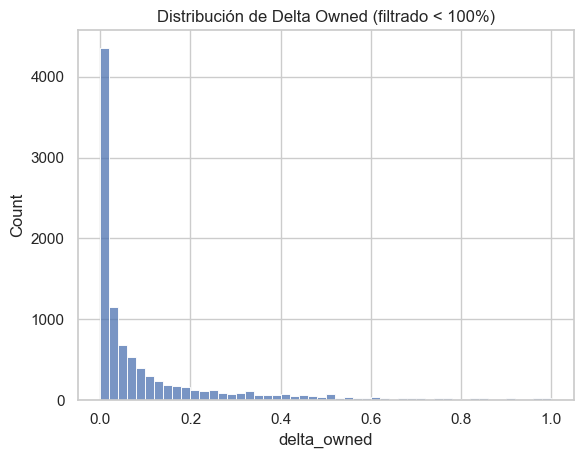

In [23]:
df['delta_owned'] = np.where(
    df['owned_after_cleaned'] != 0,
    df['qty_cleaned'] / df['owned_after_cleaned'],
    0
)

sns.histplot(df[df['delta_owned'] < 1]['delta_owned'], bins=50)
plt.title("Distribución de Delta Owned (filtrado < 100%)")

### 4.2 Reporting Lag
Días transcurridos entre el trade y la publicación.

Text(0.5, 1.0, 'Días de retraso en el reporte (Reporting Lag)')

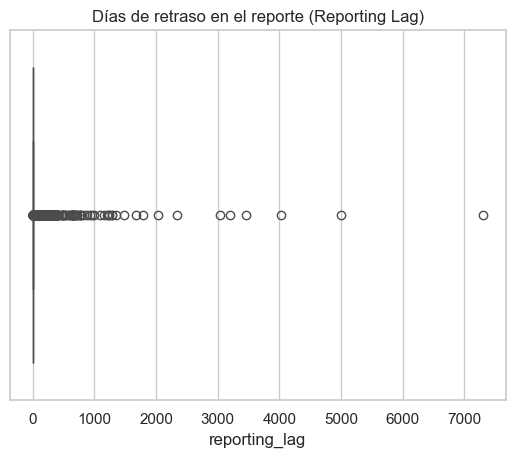

In [24]:
df['reporting_lag'] = (df['filing_date'] - df['trade_date']).dt.days

sns.boxplot(x=df['reporting_lag'])
plt.title("Días de retraso en el reporte (Reporting Lag)")

### 4.3 Insider Roles
Agrupamos y visualizamos quién está comprando.

Proporción de C-Level: 22.82%


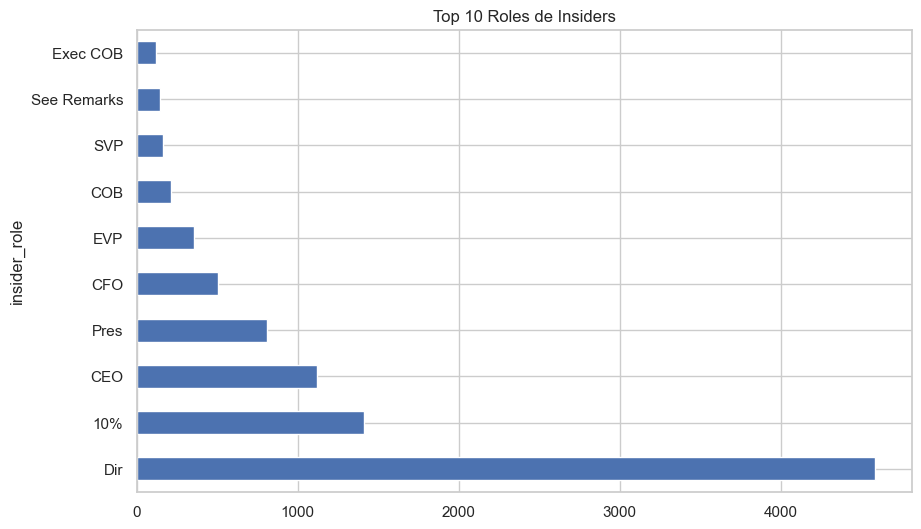

In [25]:
df['insider_role'] = df['Title'].str.split(',').str[0].str.strip()

# Identificar C-Level (CEO, CFO, etc.)
c_level_titles = ['CEO', 'CFO', 'COO', 'President', 'EVP', 'SVP']
df['is_c_level'] = df['insider_role'].apply(lambda x: any(title in str(x) for title in c_level_titles))

plt.figure(figsize=(10,6))
df['insider_role'].value_counts().nlargest(10).plot(kind='barh')
plt.title("Top 10 Roles de Insiders")
print(f"Proporción de C-Level: {df['is_c_level'].mean():.2%}")

### 4.4 Agrupación por Evento (Cluster Buy)
Calculamos cuántos insiders diferentes han comprado la misma acción en la misma fecha. Una 'compra en manada' es una señal muy fuerte.

Text(0.5, 0, 'Insiders por Evento')

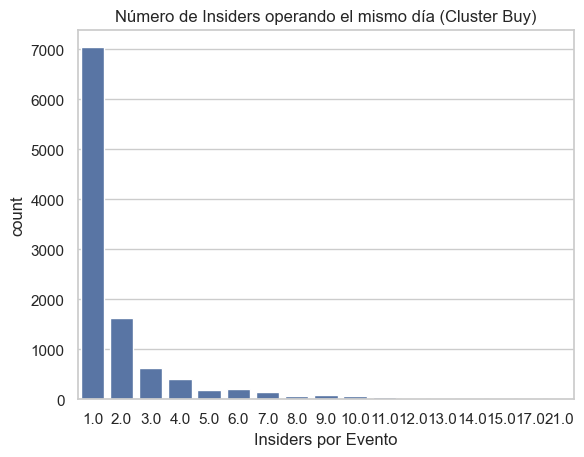

In [26]:
df['cluster_buy'] = df.groupby(['ticker', 'trade_date'])['ticker'].transform('count')

sns.countplot(x=df['cluster_buy'])
plt.title("Número de Insiders operando el mismo día (Cluster Buy)")
plt.xlabel("Insiders por Evento")

## 5. Exportar Datos Procesados

In [27]:
output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

columns_to_save = [
    'ticker', 'filing_date', 'trade_date', 'insider_role', 
    'transaction_value', 'delta_owned', 'owned_pct_change', 
    'reporting_lag', 'is_c_level', 'cluster_buy'
]

df[columns_to_save].to_parquet(output_dir / "insider_trades_processed.parquet", index=False)
print("¡Datos guardados con éxito!")

¡Datos guardados con éxito!
